In [2]:
import pandas as pd
from datetime import datetime

## Read training and test datasets

In [4]:
# helper function for reading datatset
def read_data(file_path):
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d') # convert it to datatime

    return df

In [5]:
df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

len(df_train), len(df_test)

(986, 244)

In [6]:
# the training dataset has daily KOSPI index from 2019 to 2022
df_train

,Date,Open,Low,High,Close,Volume
0,2019-01-02,2050.550049,2004.270020,2053.449951,2010.000000,326400
1,2019-01-03,2011.810059,1991.650024,2014.719971,1993.699951,428000
2,2019-01-04,1992.400024,1984.530029,2011.560059,2010.250000,409000
3,2019-01-07,2034.239990,2030.900024,2048.060059,2037.099976,440200
4,2019-01-08,2038.680054,2023.589966,2042.699951,2025.270020,397800
...,...,...,...,...,...,...
981,2022-12-23,2325.860107,2311.899902,2333.080078,2313.689941,367000
982,2022-12-26,2312.540039,2304.199951,2321.919922,2317.139893,427600
983,2022-12-27,2327.520020,2321.479980,2335.989990,2332.790039,448300
984,2022-12-28,2296.449951,2276.899902,2296.449951,2280.449951,405700


In [7]:
# the test dataset has daily KOSPI index in 2023
df_test

,Date,Open,Low,High,Close,Volume
0,2023-01-02,2249.949951,2222.370117,2259.879883,2225.669922,346100
1,2023-01-03,2230.979980,2180.669922,2230.979980,2218.679932,410000
2,2023-01-04,2205.979980,2198.820068,2260.060059,2255.979980,412700
3,2023-01-05,2268.199951,2252.969971,2281.389893,2264.649902,430800
4,2023-01-06,2253.399902,2253.270020,2300.620117,2289.969971,398300
...,...,...,...,...,...,...
239,2023-12-21,2598.370117,2587.159912,2610.810059,2600.020020,578300
240,2023-12-22,2617.719971,2599.510010,2621.370117,2599.510010,466000
241,2023-12-26,2609.439941,2594.649902,2612.139893,2602.590088,439500
242,2023-12-27,2599.350098,2590.080078,2613.500000,2613.500000,349700


## Part 1. Train regression models to predict the next day's `close` using `Open`, `Low`, `High`, `Close`, `Volume` of previous days as predictors using *only* df_train. Cross-validate to select the best model. Evaluate the accuracy of your model using `df_test`.


Train data shape: (986, 6)
Test data shape: (244, 6)

Processed Train data shape (X, y): (984, 5), (984,)
Processed Test data shape (X, y): (242, 5), (242,)

Processed Train data sample (X) - After fixing leakage:
     Open_lag1     Low_lag1    High_lag1   Close_lag1  Volume_lag1
1  2050.550049  2004.270020  2053.449951  2010.000000     326400.0
2  2011.810059  1991.650024  2014.719971  1993.699951     428000.0
3  1992.400024  1984.530029  2011.560059  2010.250000     409000.0
4  2034.239990  2030.900024  2048.060059  2037.099976     440200.0
5  2038.680054  2023.589966  2042.699951  2025.270020     397800.0

Processed Train data sample (y) - Target:
1    2010.250000
2    2037.099976
3    2025.270020
4    2064.709961
5    2063.280029
Name: Close_future, dtype: float64

Performing Time Series Cross-Validation on training data (after fixing leakage)...
Cross-validation scores (Negative MSE for each split): [-2162.56262182 -4289.83621267 -2314.82593877 -1892.79666749
 -1623.93526186]
Aver

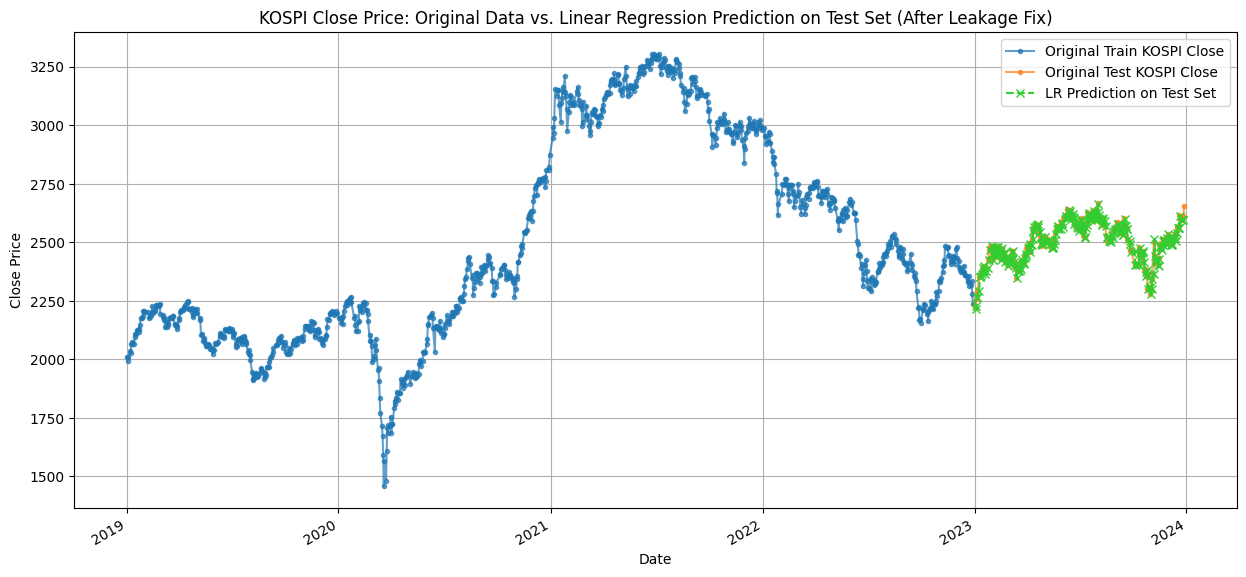

In [ ]:
# GOOD LUCK
import pandas as pd
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 로딩 및 전처리 (이전과 동일)
def read_data(file_path):
    """
    CSV 파일을 읽고 'Date' 컬럼을 datetime 형식으로 변환하는 헬퍼 함수
    """
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
    df = df.sort_values(by='Date').reset_index(drop=True)
    return df

df_train = read_data('data/kospi_train.csv')
df_test = read_data('data/kospi_test.csv')

print(f"Train data shape: {df_train.shape}")
print(f"Test data shape: {df_test.shape}")


# 2. 특성 공학 수정: 데이터 누출 방지
def create_lagged_features_no_leakage(df):
    """
    데이터 누출을 방지하며 이전 날의 데이터를 특성으로, 다음 날의 Close를 타겟으로 하는 데이터셋 생성
    """
    # 사용할 특성 컬럼 목록
    features_list = ['Open', 'Low', 'High', 'Close', 'Volume'] # 이전 날짜의 이 컬럼들을 특성으로 사용
    target_col = 'Close' # 다음 날짜의 이 컬럼을 타겟으로 사용

    # 이전 날 데이터 (특성)
    # shift(1)을 사용하여 모든 특성 컬럼을 한 행 아래로 이동시킵니다.
    X_lagged = df[features_list].shift(1)

    # 타겟 데이터프레임 (다음 날 데이터)
    # shift(-1)을 사용하여 'Close' 컬럼을 한 행 위로 이동시킵니다.
    y_shifted = df[target_col].shift(-1)

    # --- 데이터 누출 방지를 위한 컬럼 이름 변경 및 결합 ---
    # X_lagged의 컬럼 이름을 변경하여 y_shifted(Series)의 이름('Close')과 충돌하지 않도록 합니다.
    # 이렇게 하면 concat 시에 'Close'라는 이름의 컬럼이 두 개 생기는 것을 방지할 수 있습니다.
    X_lagged.columns = [f'{col}_lag1' for col in features_list]

    # y_shifted(Series)를 데이터프레임으로 변환하면서 타겟 컬럼 이름 지정
    y_df = y_shifted.to_frame(name=f'{target_col}_future') # 타겟 컬럼 이름 명시적으로 지정

    # X_lagged와 y_df를 결합합니다.
    # 이제 특성 컬럼 이름들은 '_lag1'으로 끝나고, 타겟 컬럼은 '_future'로 끝나 이름 충돌이 없습니다.
    combined_df = pd.concat([X_lagged, y_df], axis=1)
    # -------------------------------------------------

    # NaN 값 제거
    combined_df.dropna(inplace=True)

    # NaN이 제거된 데이터에서 다시 X와 y를 분리합니다.
    # 이제 X_processed에는 '_lag1'으로 끝나는 특성 컬럼만 포함됩니다.
    X_processed = combined_df[[f'{col}_lag1' for col in features_list]]
    # y_processed에는 '_future'로 끝나는 타겟 컬럼만 포함됩니다.
    y_processed = combined_df[f'{target_col}_future']

    # 해당 데이터의 'Date' 컬럼도 함께 가져옵니다.
    dates_processed = df.loc[combined_df.index, 'Date']

    return X_processed, y_processed, dates_processed

# 훈련 데이터셋에 수정된 특성 공학 적용
X_train, y_train, dates_train = create_lagged_features_no_leakage(df_train)

# 테스트 데이터셋에 수정된 특성 공학 적용
X_test, y_test, dates_test = create_lagged_features_no_leakage(df_test)

print(f"\nProcessed Train data shape (X, y): {X_train.shape}, {y_train.shape}")
print(f"Processed Test data shape (X, y): {X_test.shape}, {y_test.shape}")
print("\nProcessed Train data sample (X) - After fixing leakage:")
print(X_train.head()) # 이제 'Close' 컬럼이 하나만 있어야 합니다 (Close_lag1)
print("\nProcessed Train data sample (y) - Target:")
print(y_train.head())


# 3. 선형 회귀 모델 객체 생성 (이전과 동일)
slr = LinearRegression()


# 4. 교차 검증 (훈련 데이터 내 검증 세트 활용 및 오버피팅 방지/감지) (이전과 동일)
# TimeSeriesSplit 설정
tscv = TimeSeriesSplit(n_splits=5)

# cross_val_score 사용하여 교차 검증 수행 (검증 세트 활용 단계)
print("\nPerforming Time Series Cross-Validation on training data (after fixing leakage)...")
cv_scores = cross_val_score(slr, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error')

print("Cross-validation scores (Negative MSE for each split):", cv_scores)
average_cv_mse = -cv_scores.mean()
print(f"Average CV MSE (across validation sets): {average_cv_mse:.4f}")
std_cv_mse = cv_scores.std()
print(f"Standard deviation of CV MSE: {std_cv_mse:.4f}")

# 이제 교차 검증 점수는 0이 아닌 현실적인 값이 나올 것입니다.
# 이 점수가 모델의 일반화 성능에 대한 더 나은 추정치입니다.


# 5. 최종 모델 훈련 (전체 훈련 데이터 사용) (이전과 동일)
slr.fit(X_train, y_train)
print("\nFinal model training complete on the entire processed training data.")


# 6. 테스트 세트 평가 (모델의 최종, 독립적인 성능 평가)
y_test_prediction = slr.predict(X_test)

# 실제 테스트 타겟(y_test)과 예측 값(y_test_prediction)을 비교하여 성능 평가 지표 계산
mse = mean_squared_error(y_test, y_test_prediction)
r2 = r2_score(y_test, y_test_prediction)

print(f"\n--- Final Evaluation on Test Set (After fixing leakage) ---")
print(f"Mean Squared Error on Test Set: {mse:.4f}") # 이제 0이 아닌 현실적인 값
print(f"R-squared on Test Set: {r2:.4f}")       # 이제 1.0이 아닌 현실적인 값
print("------------------------------------------------------------")


# 7. 시각화 (이전과 동일, 날짜 데이터 처리만 확인)
plt.figure(figsize=(15, 7))

# 원본 훈련 데이터
plt.plot(df_train['Date'], df_train['Close'], '.-', label='Original Train KOSPI Close', alpha=0.7)

# 원본 테스트 데이터
plt.plot(df_test['Date'], df_test['Close'], '.-', label='Original Test KOSPI Close', alpha=0.7)

# 테스트 데이터에 대한 모델의 예측
# X축은 테스트 데이터의 날짜 (dates_test)를 사용
plt.plot(dates_test, y_test_prediction, color='limegreen', linestyle='--', marker='x', label='LR Prediction on Test Set')

plt.title('KOSPI Close Price: Original Data vs. Linear Regression Prediction on Test Set (After Leakage Fix)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()

plt.show()

## Part 2. Extend the regression model by adding some extra features of your choice. You can use any statistics publicly available. 


Cleaning DJI data...
DJI data cleaning complete.

KOSPI Train data shape: (986, 6)
DJI Train data shape: (1008, 7)
KOSPI Test data shape: (244, 6)
DJI Test data shape: (250, 7)

Merged Train data shape: (955, 12)
Merged Test data shape: (236, 12)

Merged Train data sample (after cleaning and merging):
        Date   Open_kospi    Low_kospi   High_kospi  Close_kospi  \
0 2019-01-02  2050.550049  2004.270020  2053.449951  2010.000000   
1 2019-01-03  2011.810059  1991.650024  2014.719971  1993.699951   
2 2019-01-04  1992.400024  1984.530029  2011.560059  2010.250000   
3 2019-01-07  2034.239990  2030.900024  2048.060059  2037.099976   
4 2019-01-08  2038.680054  2023.589966  2042.699951  2025.270020   

   Volume_kospi  Close_dji  Open_dji  High_dji   Low_dji   Volume_dji Change %  
0        326400   23346.24  23058.61  23413.47  22928.59  321570000.0    0.08%  
1        428000   22686.22  23176.39  23176.39  22638.41  424240000.0   -2.83%  
2        409000   23433.16  22894.92  23518.

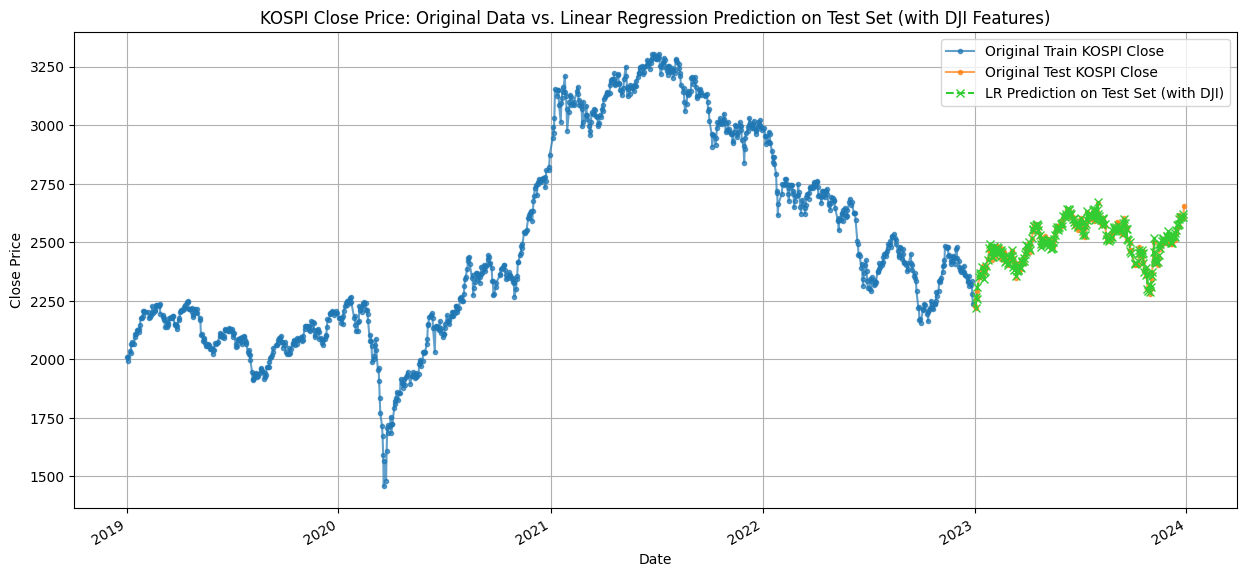

In [3]:
# GOOD 
import pandas as pd
from datetime import datetime
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. 데이터 로딩 및 전처리
def read_data(file_path):
    """
    CSV 파일을 읽고 'Date' 컬럼을 datetime 형식으로 변환하고 날짜 순으로 정렬하는 헬퍼 함수
    """
    df = pd.read_csv(file_path)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')
    df = df.sort_values(by='Date').reset_index(drop=True)
    return df

# DJI 데이터 수치 컬럼 클리닝 함수 추가
def clean_dji_data(df):
    """
    DJI 데이터프레임의 수치형 컬럼에서 쉼표와 Volume의 'M'을 제거하고 float으로 변환
    """
    # 쉼표를 제거할 컬럼 목록
    cols_to_clean_comma = ['Open', 'Low', 'High', 'Close']
    # Volume 컬럼 (단위 접미사 제거 및 변환 필요)
    col_to_clean_volume = 'Volume'

    # 쉼표 제거 및 float 변환
    for col in cols_to_clean_comma:
        # 데이터 타입이 object(문자열)인 경우에만 처리하도록 조건 추가 (안전성 확보)
        if df[col].dtype == 'object':
            # 쉼표 제거 후 수치형으로 변환 (변환 실패 시 NaN 처리)
            df[col] = df[col].astype(str).str.replace(',', '', regex=False)
            df[col] = pd.to_numeric(df[col], errors='coerce') # errors='coerce'는 변환 불가 값을 NaN으로 만듦

    # Volume 컬럼 'M' 제거 및 float 변환 (백만 단위 가정)
    if df[col_to_clean_volume].dtype == 'object':
         # 'M' 제거 후 수치형으로 변환 (변환 실패 시 NaN 처리)
        df[col_to_clean_volume] = df[col_to_clean_volume].astype(str).str.replace('M', '', regex=False)
        df[col_to_clean_volume] = pd.to_numeric(df[col_to_clean_volume], errors='coerce')
        # 백만 단위이므로 1,000,000을 곱합니다.
        df[col_to_clean_volume] = df[col_to_clean_volume] * 1_000_000 # 1e6 보다 1_000_000이 가독성 좋음

    # Note: 변환 과정에서 발생한 NaN 값은 이후 create_features 함수에서 dropna()로 처리됩니다.

    return df


# KOSPI 및 DJI 데이터셋 로딩
df_kospi_train = read_data('data/kospi_train.csv')
df_kospi_test = read_data('data/kospi_test.csv')
df_dji_train = read_data('data/DJI_train.csv')
df_dji_test = read_data('data/DJI_test.csv')

# --- DJI 데이터 클리닝 추가 ---
print("\nCleaning DJI data...")
df_dji_train = clean_dji_data(df_dji_train)
df_dji_test = clean_dji_data(df_dji_test)
print("DJI data cleaning complete.")
# --------------------------


print(f"\nKOSPI Train data shape: {df_kospi_train.shape}")
print(f"DJI Train data shape: {df_dji_train.shape}")
print(f"KOSPI Test data shape: {df_kospi_test.shape}")
print(f"DJI Test data shape: {df_dji_test.shape}")


# 2. KOSPI와 DJI 데이터 병합 (이전과 동일)
merged_train_df = pd.merge(df_kospi_train, df_dji_train, on='Date', suffixes=('_kospi', '_dji'), how='inner')
merged_test_df = pd.merge(df_kospi_test, df_dji_test, on='Date', suffixes=('_kospi', '_dji'), how='inner')

print(f"\nMerged Train data shape: {merged_train_df.shape}")
print(f"Merged Test data shape: {merged_test_df.shape}")
print("\nMerged Train data sample (after cleaning and merging):")
print(merged_train_df.head()) # 이제 DJI 컬럼에 쉼표 없이 수치형으로 표시될 것임


# 3. 특성 공학: 당일 KOSPI 및 DJI 데이터로 다음 날 KOSPI 종가 예측 (이전과 동일)
def create_features_with_dji(merged_df):
    """
    병합된 데이터에서 당일 KOSPI 및 DJI OHLCV를 특성으로, 다음 날 KOSPI 종가를 타겟으로 데이터셋 생성
    """
    kospi_features = [f'{col}_kospi' for col in ['Open', 'Low', 'High', 'Close', 'Volume']]
    dji_features = [f'{col}_dji' for col in ['Open', 'Low', 'High', 'Close', 'Volume']]

    all_features = kospi_features + dji_features

    target_col = 'Close_kospi'

    # 특성 데이터프레임 (당일 KOSPI 및 DJI 데이터)
    X = merged_df[all_features]

    # 타겟 데이터프레임 (다음 날 KOSPI 종가)
    y = merged_df[target_col].shift(-1)

    # NaN 값 처리 (마지막 행 제거)
    X_processed = X.iloc[:-1]
    y_processed = y.iloc[:-1]

    # 해당 데이터의 'Date' 컬럼도 함께 가져옵니다.
    dates_processed = merged_df['Date'].iloc[:-1]

    return X_processed, y_processed, dates_processed

# 훈련 데이터셋에 특성 공학 적용
X_train, y_train, dates_train = create_features_with_dji(merged_train_df)

# 테스트 데이터셋에 특성 공학 적용
X_test, y_test, dates_test = create_features_with_dji(merged_test_df)

print(f"\nProcessed Train data shape (X, y): {X_train.shape}, {y_train.shape}")
print(f"Processed Test data shape (X, y): {X_test.shape}, {y_test.shape}")
print("\nProcessed Train data sample (X):")
print(X_train.head())
print("\nProcessed Train data sample (y) - Target:")
print(y_train.head())


# 4. 선형 회귀 모델 객체 생성 (이전과 동일)
slr = LinearRegression()


# 5. 교차 검증 (훈련 데이터 내 검증 세트 활용 및 오버피팅 방지/감지)
print("\nPerforming Time Series Cross-Validation on training data (with DJI features)...")
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = cross_val_score(slr, X_train, y_train, cv=tscv, scoring='neg_mean_squared_error')

print("Cross-validation scores (Negative MSE for each split):", cv_scores)
average_cv_mse = -cv_scores.mean()
print(f"Average CV MSE (across validation sets): {average_cv_mse:.4f}")
std_cv_mse = cv_scores.std()
print(f"Standard deviation of CV MSE: {std_cv_mse:.4f}")


# 6. 최종 모델 훈련 (전체 훈련 데이터 사용)
slr.fit(X_train, y_train)
print("\nFinal model training complete on the entire processed training data.")


# 7. 테스트 세트 평가 (모델의 최종, 독립적인 성능 평가)
y_test_prediction = slr.predict(X_test)

mse = mean_squared_error(y_test, y_test_prediction)
r2 = r2_score(y_test, y_test_prediction)

print(f"\n--- Final Evaluation on Test Set (with DJI features) ---")
print(f"Mean Squared Error on Test Set: {mse:.4f}")
print(f"R-squared on Test Set: {r2:.4f}")
print("---------------------------------------------------------")


# 8. 시각화
plt.figure(figsize=(15, 7))

plt.plot(df_kospi_train['Date'], df_kospi_train['Close'], '.-', label='Original Train KOSPI Close', alpha=0.7)
plt.plot(df_kospi_test['Date'], df_kospi_test['Close'], '.-', label='Original Test KOSPI Close', alpha=0.7)
plt.plot(dates_test, y_test_prediction, color='limegreen', linestyle='--', marker='x', label='LR Prediction on Test Set (with DJI)')

plt.title('KOSPI Close Price: Original Data vs. Linear Regression Prediction on Test Set (with DJI Features)')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.grid(True)
plt.gcf().autofmt_xdate()

plt.show()